##### Copyright 2019 The TensorFlow Authors.

In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

In [ ]:
#@title MIT License
#
# Copyright (c) 2017 François Chollet                                                                                                                    # IGNORE_COPYRIGHT: cleared by OSS licensing
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

# Transfer learning and fine-tuning

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://www.tensorflow.org/tutorials/images/transfer_learning"><img src="https://www.tensorflow.org/images/tf_logo_32px.png" />View on TensorFlow.org</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/images/transfer_learning.ipynb?force_kitty_mode=1&force_corgi_mode=1"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/docs/blob/master/site/en/tutorials/images/transfer_learning.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/docs/site/en/tutorials/images/transfer_learning.ipynb"><img src="https://www.tensorflow.org/images/download_logo_32px.png" />Download notebook</a>
  </td>
</table>

이 튜토리얼에서는 사전 훈련된 네트워크에서 전이 학습을 사용하여 고양이와 개 이미지를 분류하는 방법을 알아봅니다.

사전 훈련된 모델은 일반적으로 대규모 이미지 분류 작업을 위해 대규모 데이터세트에서 이전에 훈련된 저장된 네트워크입니다. 사전 훈련된 모델을 그대로 사용하거나 전이 학습을 사용하여 이 모델을 주어진 작업에 맞게 사용자 지정할 수 있습니다.

이미지 분류를 위한 전이 학습의 기본 원리는 모델이 크고 일반적인 데이터세트에서 훈련되면 시각적 세계의 일반적인 모델로 효과적으로 기능한다는 것입니다. 그러면 대규모 데이터세트에서 대규모 모델을 훈련하여 처음부터 시작할 필요 없이 학습된 특징 맵을 활용할 수 있습니다.

이 노트북에서는 사전 훈련된 모델을 사용자 지정하는 두 가지 방법을 시도해 보겠습니다.

1. 특징 추출: 이전 네트워크에서 학습한 표현을 사용하여 새로운 샘플에서 의미 있는 특징을 추출합니다. 사전 훈련된 모델 위에 처음부터 훈련될 새 분류기를 추가하기만 하면 이전에 데이터세트에 대해 학습한 특징 맵을 재사용할 수 있습니다.

전체 모델을 (재)학습할 필요는 없습니다. 기본 합성곱 신경망에는 이미 사진 분류에 일반적으로 유용한 특징들이 포함되어 있습니다. 그러나 사전 학습된 모델의 최종 분류 부분은 원래 분류 작업에 특화되어 있으며, 이후 모델이 학습된 클래스 집합에 따라 달라집니다.

1. 미세 조정: 고정된 모델 기반에서 상위 계층 몇 개를 고정 해제하고 새로 추가된 분류기 계층과 기본 모델의 마지막 계층을 함께 학습합니다. 이를 통해 기본 모델의 고차 특징 표현을 "미세 조정"하여 특정 작업에 더욱 적합하게 만들 수 있습니다.

일반적인 머신 러닝 워크플로를 따릅니다.

1. 데이터 검토 및 이해
1. Keras ImageDataGenerator를 사용하여 입력 파이프라인 구축
1. 모델 구성
* 사전 학습된 기본 모델(및 사전 학습된 가중치) 로드
* 분류 계층을 맨 위에 쌓기
1. 모델 학습
1. 모델 평가

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

## Data preprocessing

### Data download

이 튜토리얼에서는 수천 장의 고양이와 개 이미지가 포함된 데이터세트를 사용합니다. 이미지가 포함된 zip 파일을 다운로드하고 압축을 푼 후, `tf.keras.utils.image_dataset_from_directory` 유틸리티를 사용하여 학습 및 검증을 위한 `tf.data.Dataset` 파일을 생성합니다. 이미지 로딩에 대한 자세한 내용은 이 [튜토리얼](https://www.tensorflow.org/tutorials/load_data/images)에서 확인할 수 있습니다.

In [4]:
_URL = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'
path_to_zip = tf.keras.utils.get_file('cats_and_dogs.zip', origin=_URL, extract=True)
# PATH = os.path.join(os.path.dirname(path_to_zip), 'cats_and_dogs_filtered')

PATH = "/root/.keras/datasets/cats_and_dogs_extracted/cats_and_dogs_filtered"
train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')

BATCH_SIZE = 32
IMG_SIZE = (160, 160)

train_dataset = tf.keras.utils.image_dataset_from_directory(train_dir,
                                                            shuffle=True,
                                                            batch_size=BATCH_SIZE,
                                                            image_size=IMG_SIZE)

Found 2000 files belonging to 2 classes.


In [5]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(validation_dir,
                                                                 shuffle=True,
                                                                 batch_size=BATCH_SIZE,
                                                                 image_size=IMG_SIZE)

Found 1000 files belonging to 2 classes.


훈련 세트에서 처음 9개의 이미지와 레이블을 표시합니다.

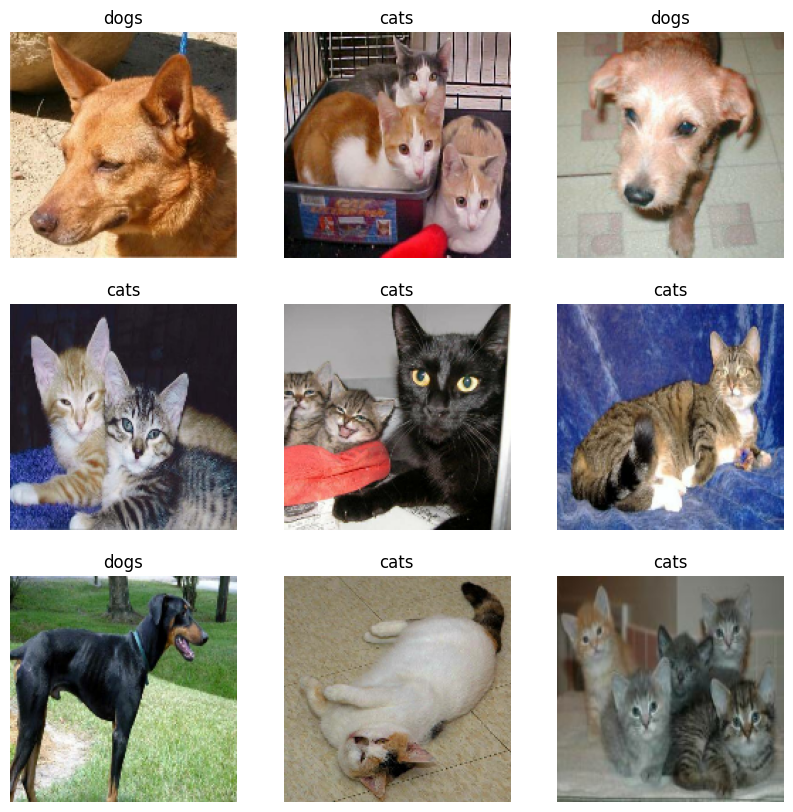

In [6]:
class_names = train_dataset.class_names

plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

원본 데이터셋에는 테스트 세트가 없으므로 테스트 세트를 생성합니다. 이를 위해 `tf.data.experimental.cardinality`를 사용하여 검증 세트에서 사용 가능한 데이터 배치 수를 확인한 다음, 그중 20%를 테스트 세트로 이동합니다.

In [7]:
val_batches = tf.data.experimental.cardinality(validation_dataset)
test_dataset = validation_dataset.take(val_batches // 5)
validation_dataset = validation_dataset.skip(val_batches // 5)

In [8]:
print('Number of validation batches: %d' % tf.data.experimental.cardinality(validation_dataset))
print('Number of test batches: %d' % tf.data.experimental.cardinality(test_dataset))

Number of validation batches: 26
Number of test batches: 6


### 성능을 위한 데이터 세트 구성

버퍼링된 프리페칭을 사용하면 I/O 차단 없이 디스크에서 이미지를 로드할 수 있습니다. 이 방법에 대한 자세한 내용은 [데이터 성능](https://www.tensorflow.org/guide/data_performance) 가이드를 참조하세요.

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

### Use data augmentation

대용량 이미지 데이터 세트가 없는 경우, 회전이나 수평 뒤집기와 같이 무작위이면서도 현실적인 변환을 훈련 이미지에 적용하여 인위적으로 샘플 다양성을 확보하는 것이 좋습니다. 이렇게 하면 모델이 훈련 데이터의 다양한 측면에 노출되고 [과적합](https://www.tensorflow.org/tutorials/keras/overfit_and_underfit)을 줄이는 데 도움이 됩니다. 데이터 증강에 대한 자세한 내용은 이 [튜토리얼](https://www.tensorflow.org/tutorials/images/data_augmentation)에서 확인할 수 있습니다.

In [10]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

참고: 이 레이어는 `Model.fit`을 호출하는 학습 중에만 활성화됩니다. `Model.evaluate`, `Model.predict` 또는 `Model.call`에서 모델이 추론 모드로 사용되는 경우에는 비활성화됩니다.

같은 이미지에 이러한 레이어를 반복해서 적용해 보고 결과를 살펴보겠습니다.

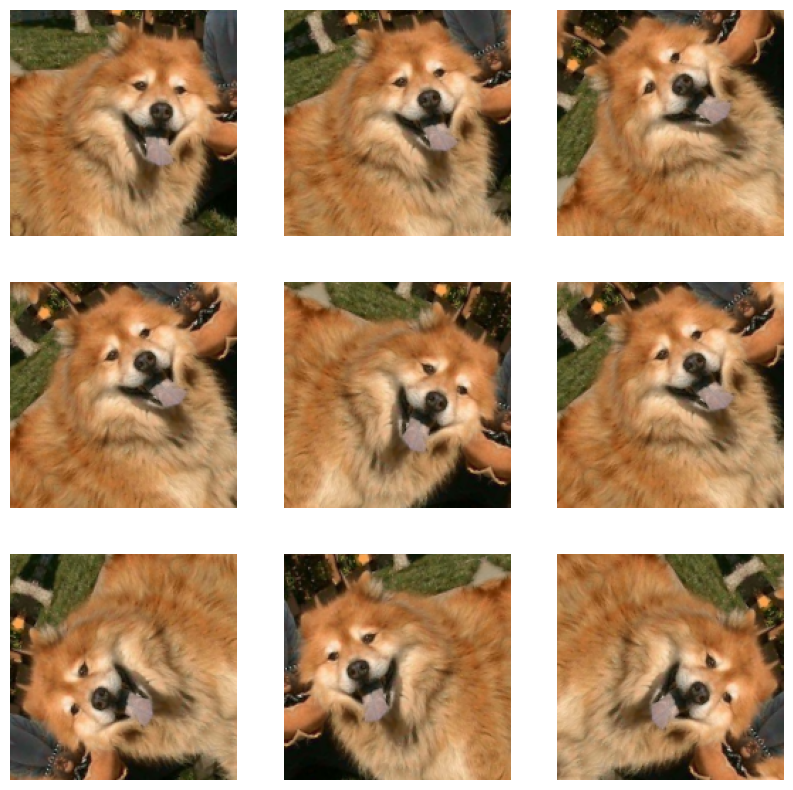

In [11]:
for image, _ in train_dataset.take(1):
  plt.figure(figsize=(10, 10))
  first_image = image[0]
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0] / 255)
    plt.axis('off')

### 픽셀 값 크기 조정

곧 기본 모델로 사용할 `tf.keras.applications.MobileNetV2`를 다운로드합니다. 이 모델은 `[-1, 1]` 범위의 픽셀 값을 예상하지만, 현재 이미지의 픽셀 값은 `[0, 255]` 범위에 있습니다. 픽셀 값을 크기 조정하려면 모델에 포함된 전처리 방법을 사용하세요.

In [12]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

참고: 또는 `tf.keras.layers.Rescaling`을 사용하여 픽셀 값을 `[0, 255]`에서 `[-1, 1]`로 조정할 수 있습니다.

In [13]:
rescale = tf.keras.layers.Rescaling(1./127.5, offset=-1)

참고: 다른 `tf.keras.applications`를 사용하는 경우 API 문서를 확인하여 `[-1, 1]` 또는 `[0, 1]`의 픽셀을 기대하는지 확인하거나 포함된 `preprocess_input` 함수를 사용하세요.

## 사전 학습된 컨브넷으로 기본 모델 생성
Google에서 개발한 **MobileNet V2** 모델을 사용하여 기본 모델을 생성합니다. 이 모델은 140만 개의 이미지와 1,000개의 클래스로 구성된 대규모 데이터셋인 ImageNet 데이터셋을 기반으로 사전 학습되었습니다. ImageNet은 `잭프루트`와 `주사기`와 같은 다양한 카테고리를 포함하는 연구 학습 데이터셋입니다. 이러한 지식 기반은 특정 데이터셋에서 고양이와 개를 분류하는 데 도움이 될 것입니다.

먼저, 특징 추출에 사용할 MobileNet V2의 계층을 선택해야 합니다. 대부분의 머신 러닝 모델 다이어그램이 아래에서 위로 진행되므로 맨 위 분류 계층은 그다지 유용하지 않습니다. 대신, 평탄화 작업 전의 맨 마지막 계층을 사용하는 일반적인 방법을 따릅니다. 이 계층을 "병목 계층"이라고 합니다. 병목 계층의 특징은 최종/맨 위 계층에 비해 더 일반성을 유지합니다.

먼저, ImageNet에서 학습된 가중치가 미리 로드된 MobileNet V2 모델을 인스턴스화합니다. **include_top=False** 인수를 지정하면 맨 위에 분류 계층을 포함하지 않는 네트워크를 로드하므로 기능 추출에 이상적입니다.

In [15]:
IMG_SIZE + (3,)

(160, 160, 3)

In [16]:
# Create the base model from the pre-trained model MobileNet V2
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


이 특징 추출기는 각 `160x160x3` 이미지를 `5x5x1280` 특징 블록으로 변환합니다. 이 함수가 이미지 배치 예시에 어떤 작업을 수행하는지 살펴보겠습니다.

In [17]:
image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 5, 5, 1280)


## 특징 추출
이 단계에서는 이전 단계에서 생성된 합성곱 기반 모델을 고정하여 특징 추출기로 사용합니다. 또한, 그 위에 분류기를 추가하고 최상위 분류기를 학습시킵니다.

### 합성곱 기반을 동결합니다

모델을 컴파일하고 학습시키기 전에 합성곱 기반 모델을 고정하는 것이 중요합니다. 고정하면(layer.trainable = False 설정) 학습 중에 특정 계층의 가중치가 업데이트되는 것을 방지할 수 있습니다. MobileNet V2에는 여러 계층이 있으므로 모델 전체의 `trainable` 플래그를 False로 설정하면 모든 계층이 고정됩니다.

In [18]:
base_model.trainable = False

### BatchNormalization 레이어에 대한 중요 참고 사항

많은 모델에 `tf.keras.layers.BatchNormalization` 레이어가 포함되어 있습니다. 이 레이어는 특수한 경우이며, 이 튜토리얼의 뒷부분에서 설명하는 것처럼 미세 조정 시 주의해야 합니다.

`layer.trainable = False`를 설정하면 `BatchNormalization` 레이어는 추론 모드에서 실행되며 평균 및 분산 통계를 업데이트하지 않습니다.

미세 조정을 위해 BatchNormalization 레이어가 포함된 모델의 고정을 해제하는 경우, 기본 모델을 호출할 때 `training = False`를 전달하여 BatchNormalization 레이어를 추론 모드로 유지해야 합니다. 그렇지 않으면 학습 불가능한 가중치에 적용된 업데이트로 인해 모델이 학습한 내용이 손상됩니다.

자세한 내용은 [전이 학습 가이드](https://www.tensorflow.org/guide/keras/transfer_learning)를 참조하세요.

In [19]:
# Let's take a look at the base model architecture
base_model.summary()

Model: "mobilenetv2_1.00_160"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

### Add a classification head

특징 블록에서 예측을 생성하려면 `tf.keras.layers.GlobalAveragePooling2D` 레이어를 사용하여 공간적 `5x5` 위치에 대한 평균을 구하고, 특징을 이미지당 1280개 요소 벡터 하나로 변환합니다.

In [20]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 1280)


`tf.keras.layers.Dense` 레이어를 적용하여 이러한 특징을 이미지당 하나의 예측으로 변환합니다. 이 예측은 `logit`, 즉 원시 예측 값으로 처리되므로 활성화 함수는 필요하지 않습니다. 양수는 클래스 1을 예측하고, 음수는 클래스 0을 예측합니다.

In [21]:
prediction_layer = tf.keras.layers.Dense(1, activation='sigmoid')
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 1)


[Keras Functional API](https://www.tensorflow.org/guide/keras/functional)를 사용하여 데이터 증강, 재조정, `base_model` 및 특징 추출기 계층을 연결하여 모델을 구축합니다. 앞서 언급했듯이 모델에 `BatchNormalization` 계층이 포함되어 있으므로 `training=False`를 사용합니다.

In [22]:
inputs = tf.keras.Input(shape=(160, 160, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

In [23]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

MobileNet의 800만 개 이상의 매개변수는 고정되어 있지만, Dense 계층에는 1200개의 _학습 가능한_ 매개변수가 있습니다. 이 매개변수들은 가중치와 편향이라는 두 개의 `tf.Variable` 객체로 나뉩니다.

In [24]:
len(model.trainable_variables)

2

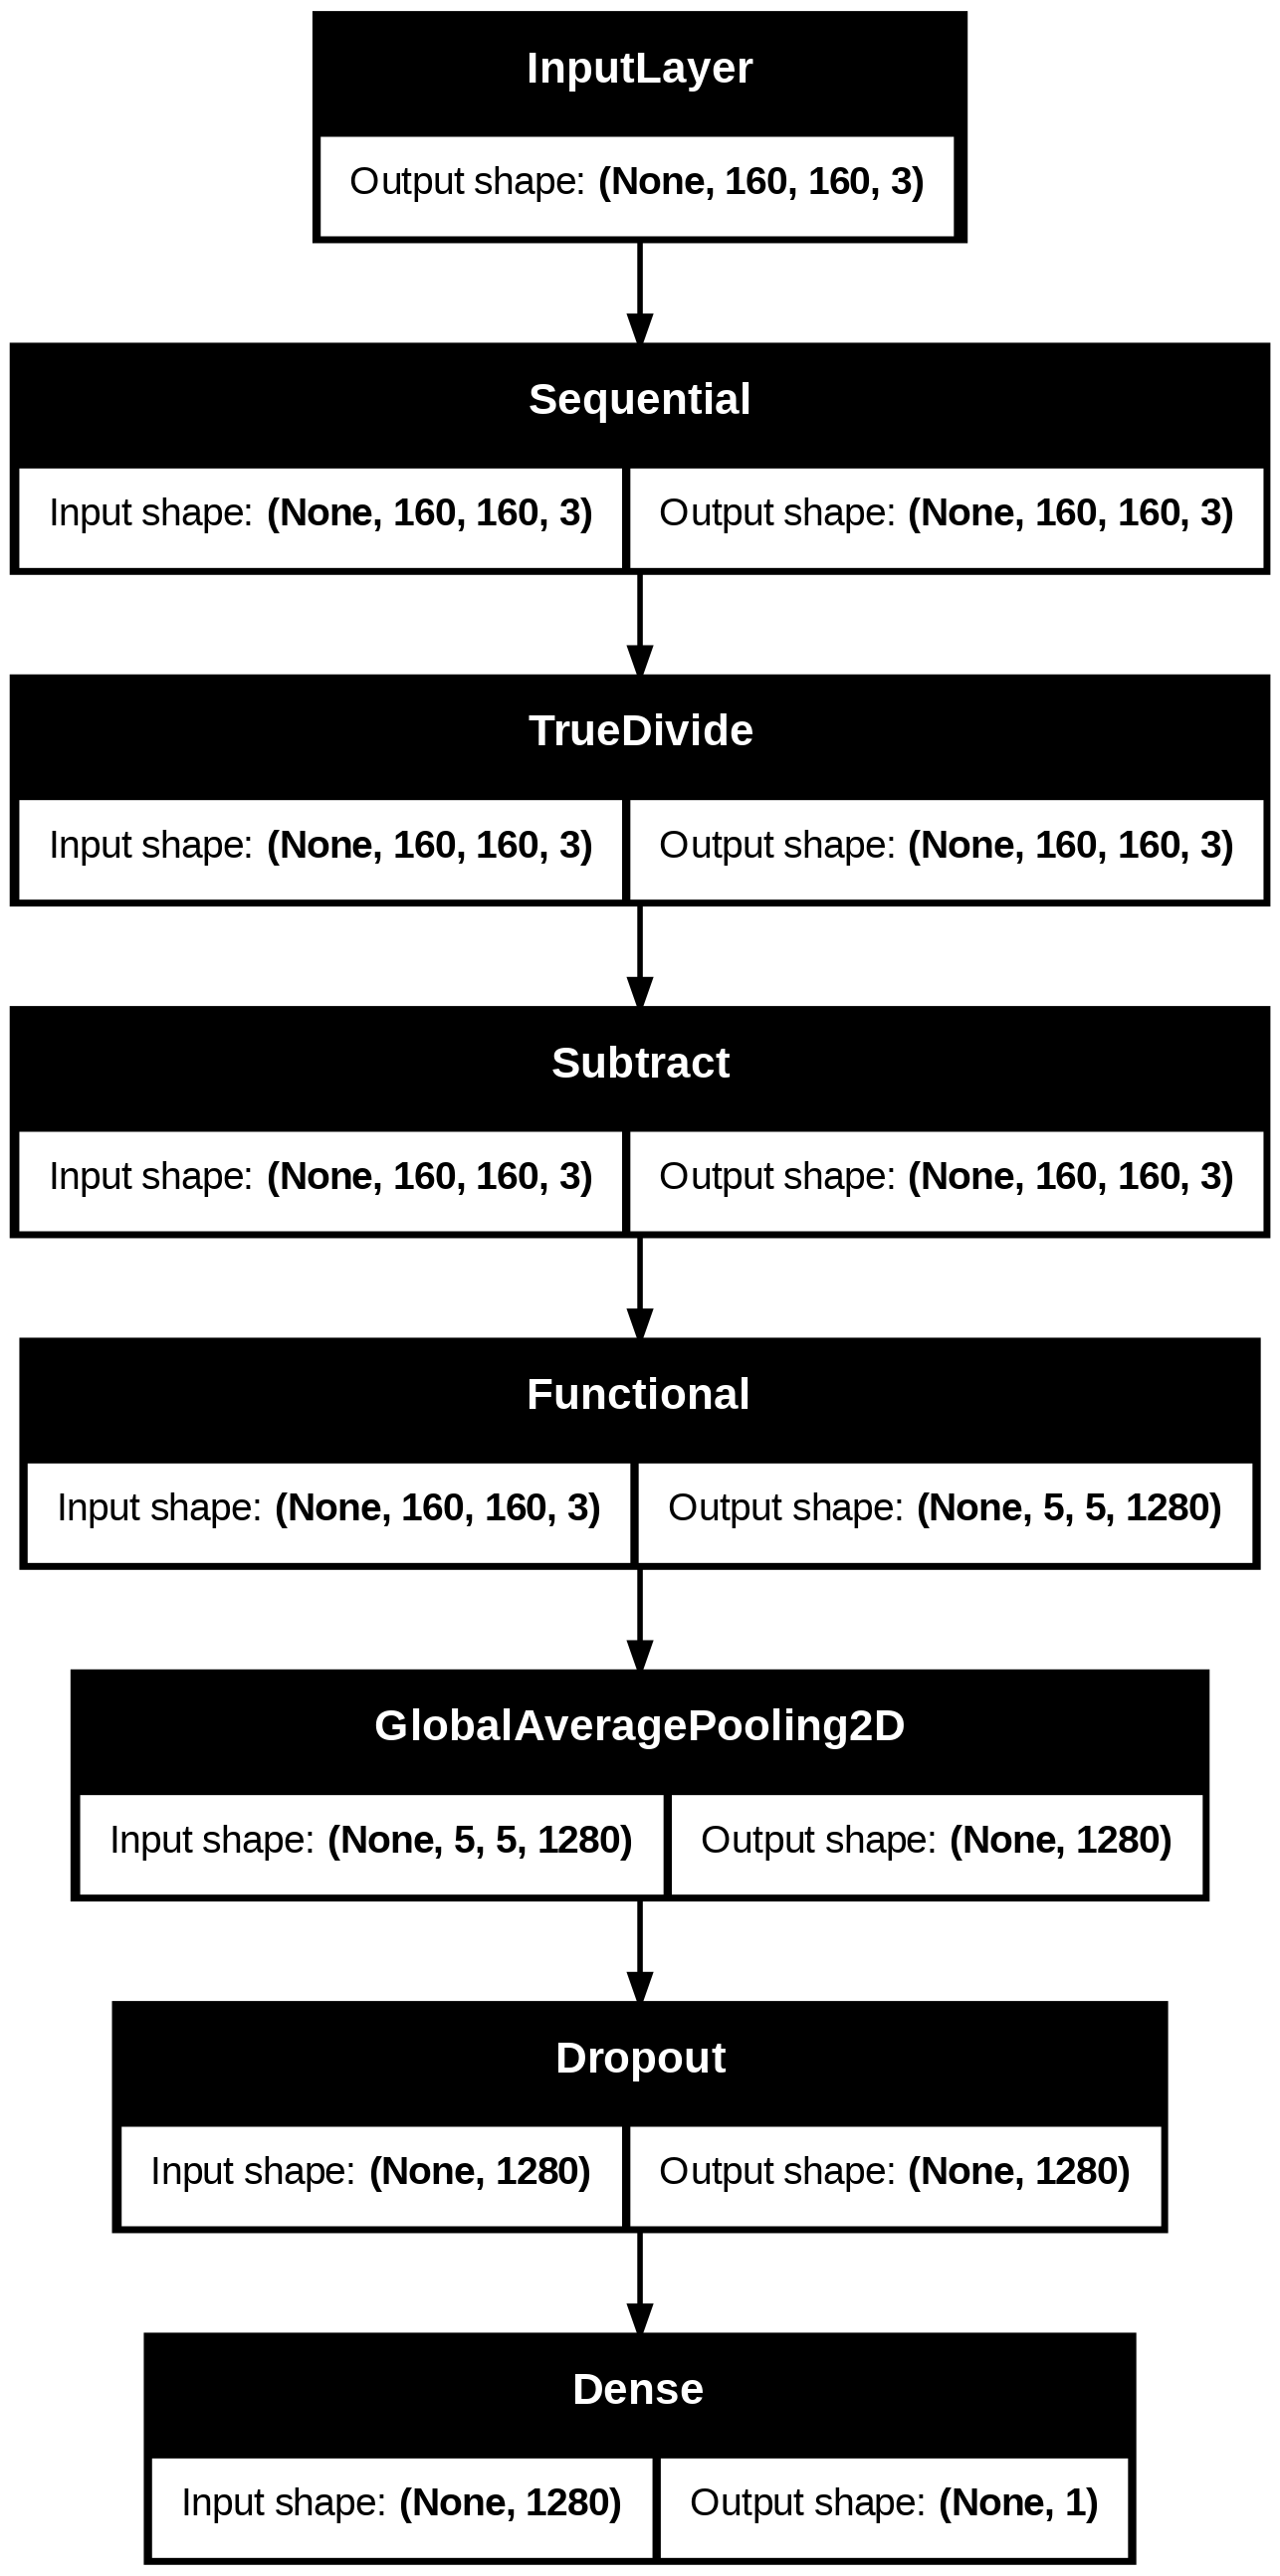

In [25]:
tf.keras.utils.plot_model(model, show_shapes=True)

### Compile the model

모델을 학습하기 전에 컴파일하세요. 두 개의 클래스와 시그모이드 출력이 있으므로 `BinaryAccuracy`를 사용하세요.

In [26]:
base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0.5, name='accuracy')])

### Train the model

10개의 에포크 동안 학습한 후에는 검증 세트에서 약 96%의 정확도를 볼 수 있습니다.


In [27]:
initial_epochs = 10

loss0, accuracy0 = model.evaluate(validation_dataset)

26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.4089 - loss: 1.0371


In [28]:
print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

initial loss: 1.03
initial accuracy: 0.40


In [29]:
history = model.fit(train_dataset,
                    epochs=initial_epochs,
                    validation_data=validation_dataset)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.4585 - loss: 0.9007 - val_accuracy: 0.6374 - val_loss: 0.6499
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.6595 - loss: 0.6232 - val_accuracy: 0.8243 - val_loss: 0.4715
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.7953 - loss: 0.4916 - val_accuracy: 0.9047 - val_loss: 0.3604
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.8375 - loss: 0.3990 - val_accuracy: 0.9344 - val_loss: 0.2903
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.8762 - loss: 0.3540 - val_accuracy: 0.9431 - val_loss: 0.2481
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.8899 - loss: 0.3023 - val_accuracy: 0.9542 - val_loss: 0.2100
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9054 - loss: 0.2707 - val_accuracy: 0.9604 - val_loss: 0.1851
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9054 - loss: 0.2510 - val_accuracy: 0.9653 - v

### Learning curves

MobileNetV2 기반 모델을 고정된 기능 추출기로 사용할 때 학습 및 검증 정확도/손실의 학습 곡선을 살펴보겠습니다.

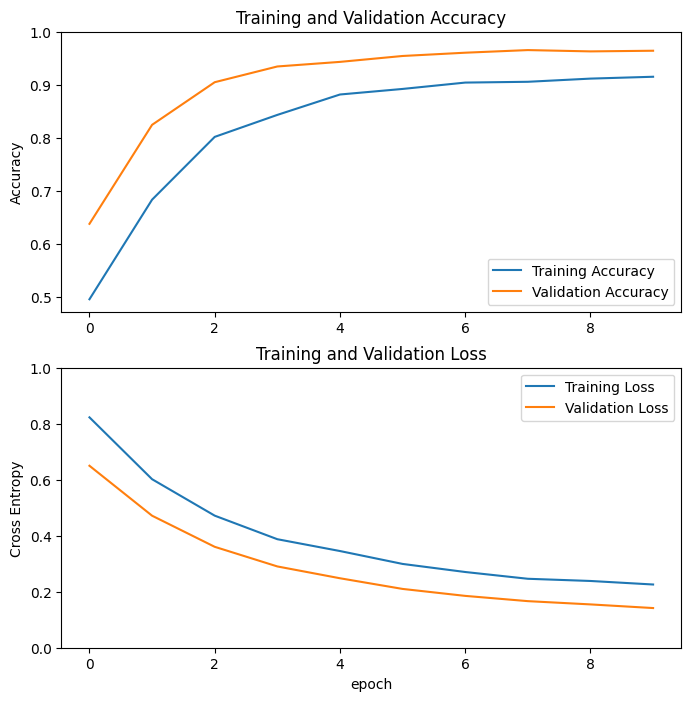

In [30]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

참고: 검증 지표가 학습 지표보다 확실히 더 나은 이유가 궁금하시다면, 주된 이유는 `tf.keras.layers.BatchNormalization` 및 `tf.keras.layers.Dropout`과 같은 레이어가 학습 중 정확도에 영향을 미치기 때문입니다. 검증 손실을 계산할 때는 이러한 레이어가 비활성화됩니다.

또한, 학습 지표는 에포크(epoch)의 평균을 보고하는 반면, 검증 지표는 에포크 이후에 평가되기 때문에, 검증 지표는 약간 더 오랫동안 학습된 모델을 고려하기 때문입니다.

## 미세 조정
특징 추출 실험에서는 MobileNetV2 기본 모델 위에 몇 개의 계층만 학습했습니다. 사전 학습된 네트워크의 가중치는 학습 중에 **업데이트되지** 않았습니다.

성능을 더욱 향상시키는 한 가지 방법은 추가한 분류기를 학습하는 것과 동시에 사전 학습된 모델의 최상위 계층의 가중치를 학습(또는 "미세 조정")하는 것입니다. 학습 과정에서 가중치는 일반 특성 맵에서 데이터 세트와 관련된 특성으로 조정됩니다.

참고: 이 작업은 사전 학습된 모델을 학습 불가능으로 설정하여 최상위 분류기를 학습한 후에만 시도해야 합니다. 사전 학습된 모델 위에 무작위로 초기화된 분류기를 추가하고 모든 계층을 함께 학습하려고 하면 분류기의 무작위 가중치로 인해 그래디언트 업데이트 크기가 너무 커지고 사전 학습된 모델이 학습한 내용을 잊어버리게 됩니다.

또한 전체 MobileNet 모델보다는 소수의 최상위 계층을 미세 조정하는 것이 좋습니다. 대부분의 합성곱 신경망에서 계층이 높아질수록 더욱 전문화됩니다. 처음 몇 개의 계층은 거의 모든 유형의 이미지에 일반화되는 매우 간단하고 일반적인 특징을 학습합니다. 계층이 높아질수록 특징들은 모델이 학습된 데이터셋에 점점 더 구체적으로 적용됩니다. 미세 조정의 목표는 일반적인 학습을 덮어쓰는 것이 아니라, 이러한 전문화된 특징들이 새로운 데이터셋에 적합하도록 조정하는 것입니다.

### 모델의 상위 레이어를 동결 해제합니다.


`base_model`의 고정을 해제하고 하위 레이어를 학습 불가능으로 설정하기만 하면 됩니다. 그런 다음, 변경 사항을 적용하려면 모델을 다시 컴파일하고 학습을 재개해야 합니다.

In [40]:
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

In [41]:
base_model.trainable = True

In [42]:
len(base_model.trainable_weights)

156

In [43]:
# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  154


In [44]:
len(base_model.trainable_weights)

54

In [45]:
inputs = tf.keras.Input(shape=(160, 160, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

### 모델 컴파일

훨씬 더 큰 모델을 학습하고 사전 학습된 가중치를 재적응시키려면 이 단계에서는 낮은 학습률을 사용하는 것이 중요합니다. 그렇지 않으면 모델이 매우 빠르게 과적합될 수 있습니다.

In [46]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer = tf.keras.optimizers.RMSprop(learning_rate=base_learning_rate/10),
              metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0.5, name='accuracy')])

In [47]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,862,721 (7.11 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [49]:
len(model.trainable_variables)

56

### Continue training the model

이전에 수렴에 대한 훈련을 했다면 이 단계를 거치면 정확도가 몇 퍼센트 향상됩니다.

In [50]:
fine_tune_epochs = 10
total_epochs =  initial_epochs + fine_tune_epochs

history_fine = model.fit(train_dataset,
                         epochs=fine_tune_epochs,
                         validation_data=validation_dataset)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 99ms/step - accuracy: 0.7909 - loss: 0.4102 - val_accuracy: 0.9715 - val_loss: 0.0905
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.8623 - loss: 0.2914 - val_accuracy: 0.9777 - val_loss: 0.0719
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.9241 - loss: 0.1988 - val_accuracy: 0.9802 - val_loss: 0.0604
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.9230 - loss: 0.2071 - val_accuracy: 0.9790 - val_loss: 0.0549
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.9345 - loss: 0.1709 - val_accuracy: 0.9814 - val_loss: 0.0514
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.9345 - loss: 0.1529 - val_accuracy: 0.9814 - val_loss: 0.0543
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.9543 - loss: 0.1475 - val_accuracy: 0.9864 - val_loss: 0.0416
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.9434 - loss: 0.1411 - val_accuracy: 0.9864 - 

MobileNetV2 기본 모델의 마지막 몇 개 계층을 미세 조정하고 그 위에 분류기를 학습시킬 때 학습 및 검증 정확도/손실의 학습 곡선을 살펴보겠습니다. 검증 손실이 학습 손실보다 훨씬 높기 때문에 과적합이 발생할 수 있습니다.

또한 새로운 학습 세트가 상대적으로 작고 기존 MobileNetV2 데이터셋과 유사하기 때문에 과적합이 발생할 수도 있습니다.


모델을 미세 조정한 후 검증 세트에서 정확도가 거의 98%에 도달했습니다.

In [51]:
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

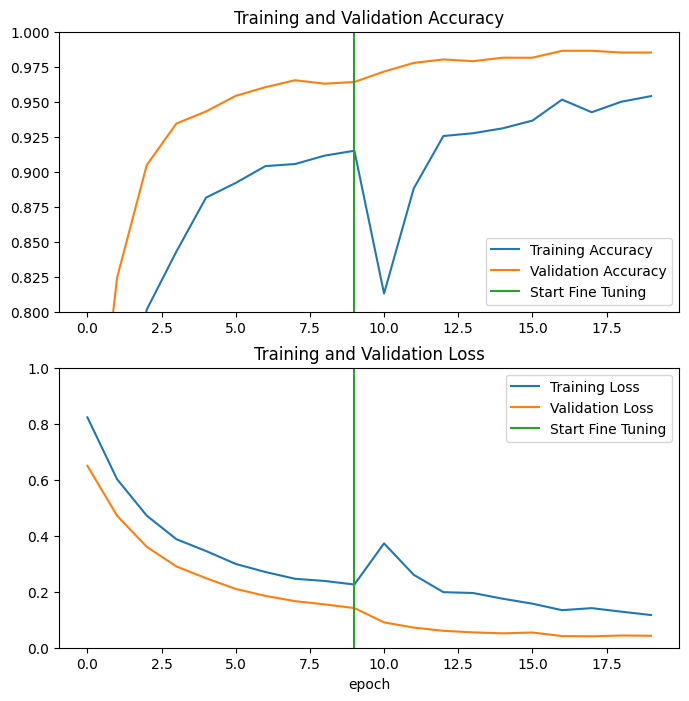

In [52]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.8, 1])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

### Evaluation and prediction

Finally you can verify the performance of the model on new data using test set.

In [53]:
loss, accuracy = model.evaluate(test_dataset)
print('Test accuracy :', accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9868 - loss: 0.0473
Test accuracy : 0.9895833134651184


이제 이 모델을 사용하여 귀하의 애완동물이 고양이인지 개인지 예측할 준비가 되었습니다.

Predictions:
 [1 1 0 1 1 1 0 1 1 0 0 1 0 1 1 0 1 1 1 0 0 1 0 1 0 1 0 0 1 0 1 1]
Labels:
 [1 1 0 1 1 1 0 1 1 0 0 1 0 1 1 0 1 1 1 0 0 1 0 1 0 1 0 0 1 0 1 1]


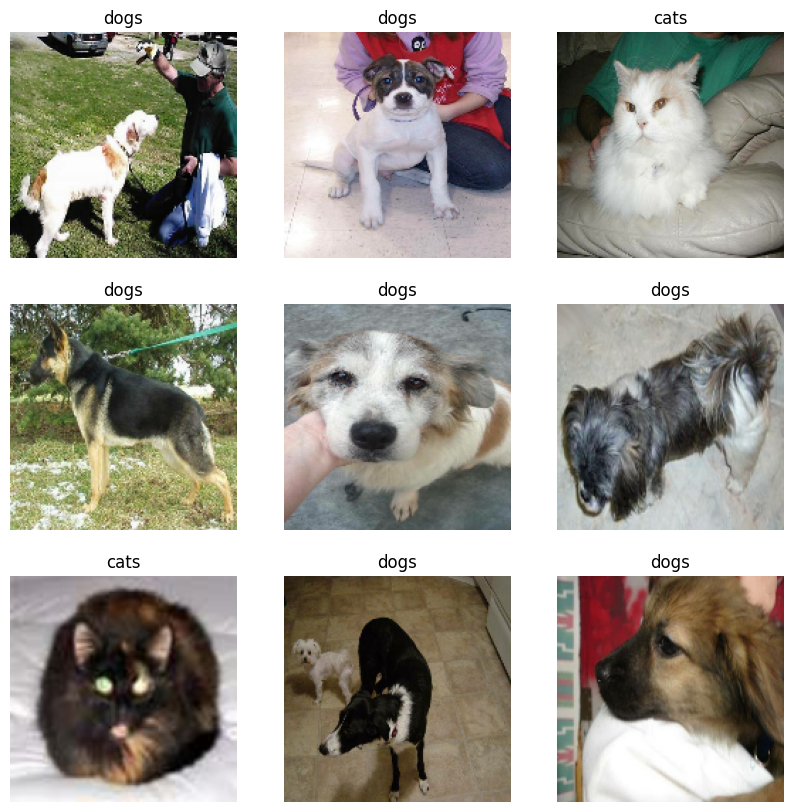

In [55]:
# Retrieve a batch of images from the test set
image_batch, label_batch = test_dataset.as_numpy_iterator().next()
predictions = model.predict_on_batch(image_batch).flatten()
predictions = tf.where(predictions < 0.5, 0, 1)

print('Predictions:\n', predictions.numpy())
print('Labels:\n', label_batch)

plt.figure(figsize=(10, 10))
for i in range(9):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image_batch[i].astype("uint8"))
  plt.title(class_names[predictions[i]])
  plt.axis("off")

## 요약

* **사전 학습된 모델을 사용한 특징 추출**: 소규모 데이터셋을 사용할 때, 동일 도메인의 대규모 데이터셋에서 학습된 모델이 학습한 특징을 활용하는 것이 일반적입니다. 이는 사전 학습된 모델을 인스턴스화하고 그 위에 완전 연결 분류기를 추가하는 방식으로 수행됩니다. 사전 학습된 모델은 "동결"되며, 학습 과정에서 분류기의 가중치만 업데이트됩니다.
이 경우, 합성곱 기반 모델은 각 이미지와 관련된 모든 특징을 추출했고, 추출된 특징 집합을 기반으로 이미지 클래스를 판별하는 분류기를 학습했습니다.

* **사전 학습된 모델 미세 조정**: 성능을 더욱 향상시키려면 미세 조정을 통해 사전 학습된 모델의 최상위 계층을 새 데이터셋에 맞게 재활용할 수 있습니다.
이 경우, 모델이 데이터셋에 특화된 상위 수준의 특징을 학습하도록 가중치를 조정했습니다. 이 기법은 일반적으로 학습 데이터 세트가 크고 사전 학습된 모델이 학습된 원본 데이터 세트와 매우 유사할 때 권장됩니다.

자세한 내용은 [전이 학습 가이드](https://www.tensorflow.org/guide/keras/transfer_learning)를 참조하세요.